<a href="https://colab.research.google.com/github/2004sayantan/E_commerce_project/blob/main/E_commerce_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Which things we are going to find after analyzing the data

Which category generates the most revenue?

Which payment method is most popular?

Who are the top 10 customers?

Which products sell the most?

Which month has the highest sales?

Total sales during the whole year?

What is the average discount?

How much revenue is generated after discounts?

Which category receives the highest discounts?

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("steve1215rogg/e-commerce-dataset")

print("Path to dataset files:", path)

100%|██████████| 89.8k/89.8k [00:00<00:00, 35.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/steve1215rogg/e-commerce-dataset/versions/1


In [ ]:
import os

print(path)
print(os.listdir(path))

/root/.cache/kagglehub/datasets/steve1215rogg/e-commerce-dataset/versions/1
['ecommerce_dataset_updated.csv']


In [ ]:
import pandas as pd

df=pd.read_csv('/root/.cache/kagglehub/datasets/steve1215rogg/e-commerce-dataset/versions/1/ecommerce_dataset_updated.csv',encoding='latin-1')
df

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024
...,...,...,...,...,...,...,...,...
3655,67abda0a,28714133-6,Beauty,486.79,0,486.79,UPI,14-05-2024
3656,34ebc1a0,08838c2c-9,Toys,212.87,15,180.94,Cash on Delivery,19-11-2024
3657,1defd3b1,c39a4f16-6,Home & Kitchen,389.76,0,389.76,Net Banking,07-08-2024
3658,0611293d,b4f67f96-9,Electronics,447.66,30,313.36,UPI,21-05-2024


In [ ]:
col=df.columns
print(col)

Index(['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)',
       'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   object 
 1   Product_ID        3660 non-null   object 
 2   Category          3660 non-null   object 
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   object 
 7   Purchase_Date     3660 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 228.9+ KB


In [ ]:
df.describe()

,Price (Rs.),Discount (%),Final_Price(Rs.)
count,3660.000000,3660.000000,3660.000000
mean,254.800675,18.825137,206.906579
std,141.682621,14.731338,122.687844
min,10.090000,0.000000,5.890000
25%,134.012500,5.000000,104.512500
50%,253.845000,15.000000,199.185000
75%,377.595000,25.000000,304.117500
max,499.960000,50.000000,496.820000


In [ ]:
df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


In [ ]:
df.tail()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
3655,67abda0a,28714133-6,Beauty,486.79,0,486.79,UPI,14-05-2024
3656,34ebc1a0,08838c2c-9,Toys,212.87,15,180.94,Cash on Delivery,19-11-2024
3657,1defd3b1,c39a4f16-6,Home & Kitchen,389.76,0,389.76,Net Banking,07-08-2024
3658,0611293d,b4f67f96-9,Electronics,447.66,30,313.36,UPI,21-05-2024
3659,e73ad07c,a5d07442-d,Home & Kitchen,235.77,30,165.04,UPI,14-04-2024


In [ ]:
df.shape

(3660, 8)

# Detecting Missing Values

In [ ]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Category,0
Price (Rs.),0
Discount (%),0
Final_Price(Rs.),0
Payment_Method,0
Purchase_Date,0


# Detecting Duplicate values

In [ ]:
df.duplicated().sum()

np.int64(0)

# Which category generates the most revenue?

In [ ]:
revenue=df.groupby(['Category'])['Final_Price(Rs.)'].sum().sort_values(ascending=False)
revenue

,Final_Price(Rs.)
Category,
Clothing,115314.84
Books,111149.35
Home & Kitchen,110328.08
Sports,108518.79
Toys,107289.69
Beauty,104215.10
Electronics,100462.23


In [ ]:
print("Maximum revenue is : ",revenue.idxmax(),"=",revenue.max())

Maximum revenue is :  Clothing = 115314.84


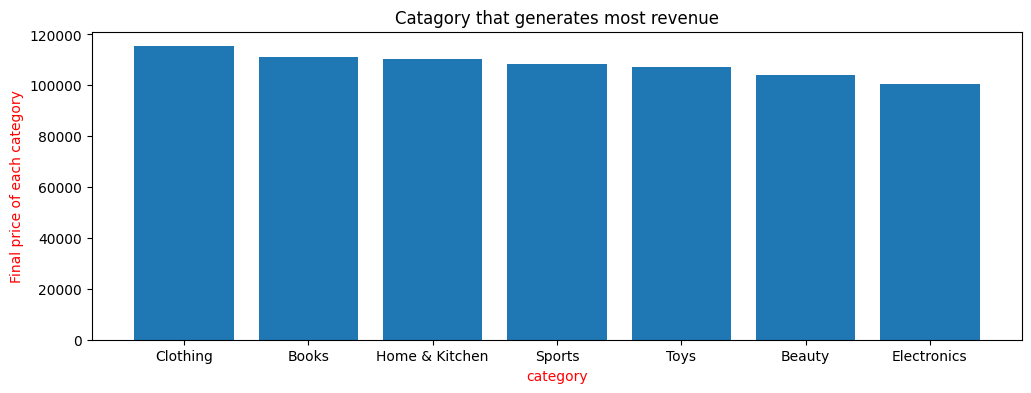

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.title('Catagory that generates most revenue')
plt.bar(revenue.index,revenue.values)
plt.xlabel('category',color='red')
plt.ylabel('Final price of each category',color='red')
plt.show()


# Which payment method is most popular?

In [ ]:
Payment_Method=df.groupby(['Payment_Method'])['Payment_Method'].count().sort_values(ascending=False)
Payment_Method

,Payment_Method
Payment_Method,
Credit Card,760
UPI,757
Debit Card,731
Net Banking,716
Cash on Delivery,696


In [ ]:
print("most popular payment method is : ",Payment_Method.idxmax(),"=",Payment_Method.max())

most popular payment method is :  Credit Card = 760


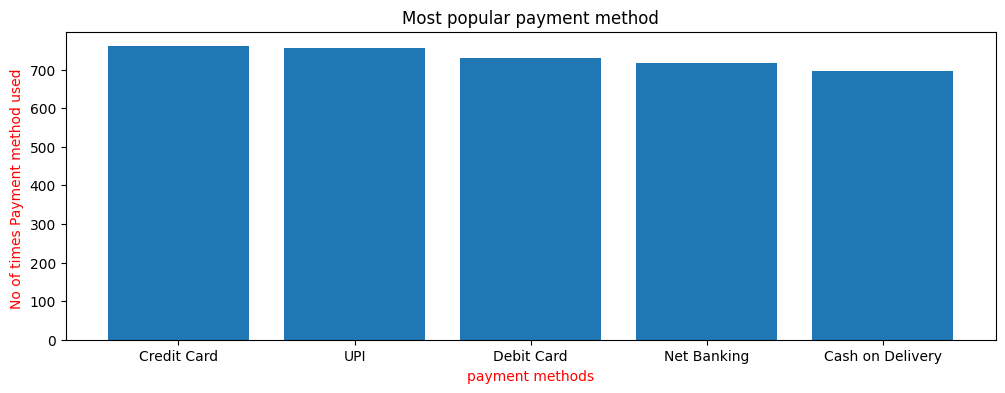

In [ ]:
plt.figure(figsize=(12,4))
plt.title('Most popular payment method')
plt.bar(Payment_Method.index,Payment_Method.values)
plt.xlabel('payment methods',color='red')
plt.ylabel('No of times Payment method used ',color='red')
plt.show()

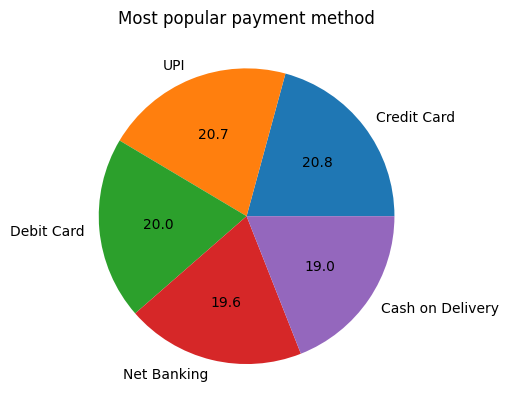

In [ ]:
plt.pie(Payment_Method,labels=Payment_Method.index,autopct='%1.1f')
plt.title('Most popular payment method')
plt.show()

# Who are the top 10 customers?

In [ ]:
customers=df.groupby(['User_ID'])['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
customers

,Final_Price(Rs.)
User_ID,
8b885340,496.82
20797b76,495.02
d8970dd2,493.04
da7bc76a,492.41
68722b9b,491.70
05e6557c,487.06
67abda0a,486.79
d646700c,484.56
edb89577,480.49


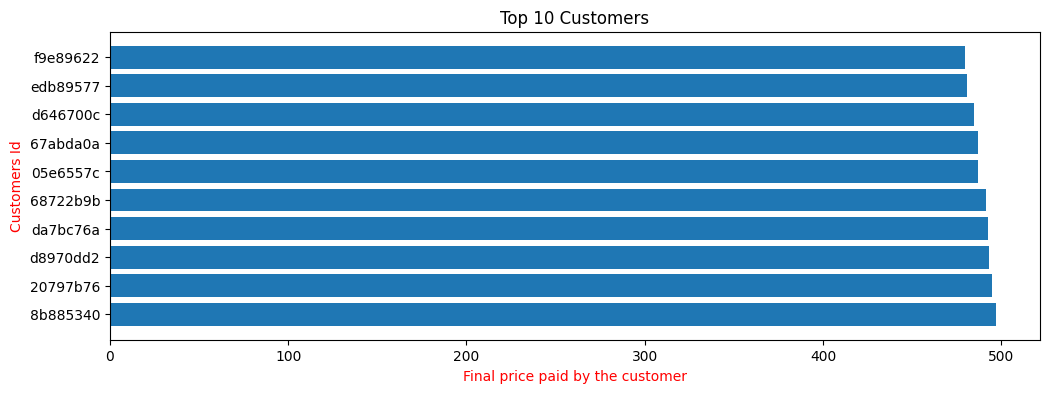

In [ ]:
plt.figure(figsize=(12,4))
plt.title("Top 10 Customers")
plt.barh(customers.index,customers.values)
plt.xlabel("Final price paid by the customer" ,color='red')
plt.ylabel('Customers Id',color='red')
plt.show()

# Which products sell the most?

In [ ]:
products_sell=df.groupby(['Product_ID'])['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(20)
products_sell

,Final_Price(Rs.)
Product_ID,
5a4c2797-7,496.82
2a8fff8b-4,495.02
475d4cf1-c,493.04
e88dc97f-5,492.41
67d7c91c-b,491.70
128bb94a-4,487.06
28714133-6,486.79
585b0773-2,484.56
3be497cb-0,480.49


In [ ]:
print("The product which was mostly sale is : ",products_sell.idxmax(),"=",products_sell.max())

The product which was mostly sale is :  5a4c2797-7 = 496.82


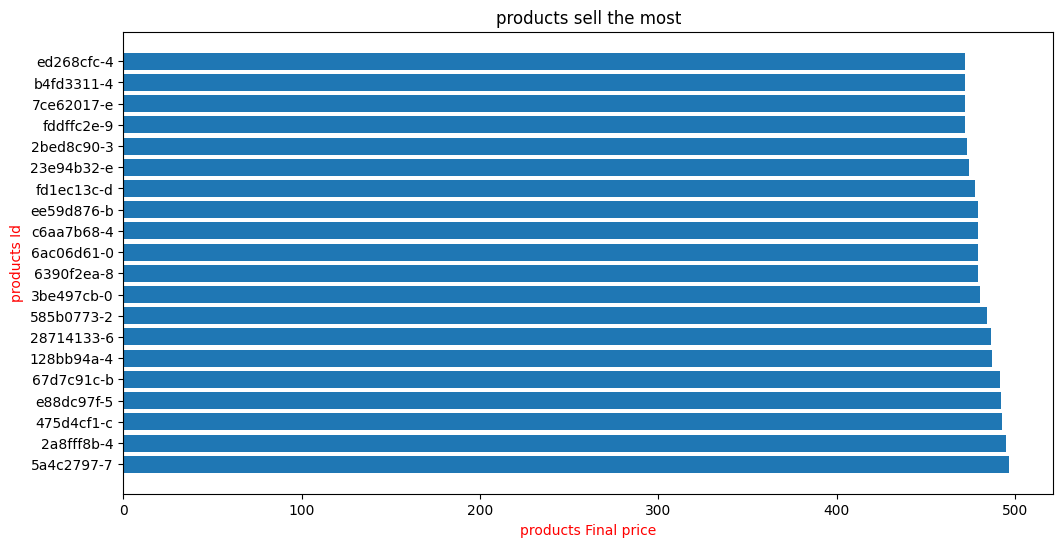

In [ ]:
plt.figure(figsize=(12,6))
plt.title("products sell the most")
plt.barh(products_sell.index,products_sell.values)
plt.xlabel("products Final price" ,color='red')
plt.ylabel('products Id',color='red')
plt.show()

# Which month has the highest sales?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   object 
 1   Product_ID        3660 non-null   object 
 2   Category          3660 non-null   object 
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   object 
 7   Purchase_Date     3660 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 228.9+ KB


In [ ]:
df['Purchase_Date']=pd.to_datetime(df['Purchase_Date'],format='%d-%m-%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           3660 non-null   object        
 1   Product_ID        3660 non-null   object        
 2   Category          3660 non-null   object        
 3   Price (Rs.)       3660 non-null   float64       
 4   Discount (%)      3660 non-null   int64         
 5   Final_Price(Rs.)  3660 non-null   float64       
 6   Payment_Method    3660 non-null   object        
 7   Purchase_Date     3660 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 228.9+ KB


In [ ]:
df['Purchase_Date']

,Purchase_Date
0,2024-11-12
1,2024-02-09
2,2024-09-01
3,2024-04-01
4,2024-09-27
...,...
3655,2024-05-14
3656,2024-11-19
3657,2024-08-07
3658,2024-05-21


In [ ]:
df['purchased_month']=df['Purchase_Date'].dt.month_name()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           3660 non-null   object        
 1   Product_ID        3660 non-null   object        
 2   Category          3660 non-null   object        
 3   Price (Rs.)       3660 non-null   float64       
 4   Discount (%)      3660 non-null   int64         
 5   Final_Price(Rs.)  3660 non-null   float64       
 6   Payment_Method    3660 non-null   object        
 7   Purchase_Date     3660 non-null   datetime64[ns]
 8   purchased_month   3660 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 257.5+ KB


In [ ]:
df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date,purchased_month
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,2024-11-12,November
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,2024-02-09,February
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,2024-09-01,September
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,2024-04-01,April
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,2024-09-27,September


In [ ]:
monthly_sales=df.groupby(['purchased_month'])['Final_Price(Rs.)'].sum().sort_values(ascending=True)
monthly_sales

,Final_Price(Rs.)
purchased_month,
November,51915.08
June,64256.66
September,68043.09
May,68837.25
January,69009.43
February,69186.34
March,71325.40
August,71506.96
July,72798.23


In [ ]:
print("Month has highest sales  : ",monthly_sales.idxmax(),"=",monthly_sales.max())

Month has highest sales  :  October = 76034.51


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


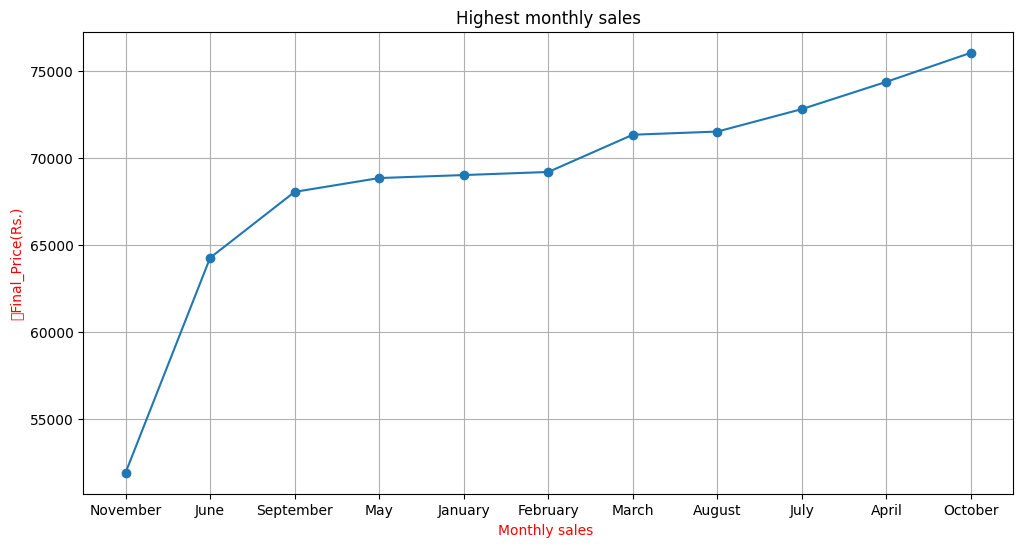

In [ ]:
plt.figure(figsize=(12,6))
plt.title('Highest monthly sales')
plt.plot(monthly_sales.index,monthly_sales.values,marker='o')
plt.grid()
plt.xlabel('Monthly sales ',color='red')
plt.ylabel('	Final_Price(Rs.)',color='red')
plt.show()

# Total sales during the whole year?

In [ ]:
df['purchased_year']=df['Purchase_Date'].dt.year
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           3660 non-null   object        
 1   Product_ID        3660 non-null   object        
 2   Category          3660 non-null   object        
 3   Price (Rs.)       3660 non-null   float64       
 4   Discount (%)      3660 non-null   int64         
 5   Final_Price(Rs.)  3660 non-null   float64       
 6   Payment_Method    3660 non-null   object        
 7   Purchase_Date     3660 non-null   datetime64[ns]
 8   purchased_month   3660 non-null   object        
 9   purchased_year    3660 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(5)
memory usage: 271.8+ KB


In [ ]:
total_year_sales=df.groupby(['purchased_year'])['Final_Price(Rs.)'].sum()
total_year_sales

,Final_Price(Rs.)
purchased_year,
2024,757278.08


# What is the average discount?

In [ ]:
avg_discount=df['Discount (%)'].mean()
print("Here average discount is : ",avg_discount)

Here average discount is :  18.825136612021858


# How much revenue is generated after discounts?

In [ ]:
df.head(10)

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date,purchased_month,purchased_year
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,2024-11-12,November,2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,2024-02-09,February,2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,2024-09-01,September,2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,2024-04-01,April,2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,2024-09-27,September,2024
5,3fdcdae8,0816ee12-5,Books,241.86,50,120.93,UPI,2024-08-08,August,2024
6,12772337,d41e0b55-c,Toys,76.91,5,73.06,Credit Card,2024-03-28,March,2024
7,9f0194af,83b7dc04-5,Sports,213.23,20,170.58,Net Banking,2024-05-29,May,2024
8,7a8559d8,87c9c896-1,Sports,379.81,5,360.82,Credit Card,2024-02-26,February,2024
9,8911f0d1,31308875-b,Home & Kitchen,415.36,50,207.68,Net Banking,2024-01-11,January,2024


In [ ]:
total_revenue_after_discount=df['Final_Price(Rs.)'].sum()
print("Total revenue after discount is : ",total_revenue_after_discount)

Total revenue after discount is :  757278.08


In [ ]:
total_revenue_before_discount=df['Price (Rs.)'].sum()
print("Total revenue after discount is : ",total_revenue_before_discount)

Total revenue after discount is :  932570.47


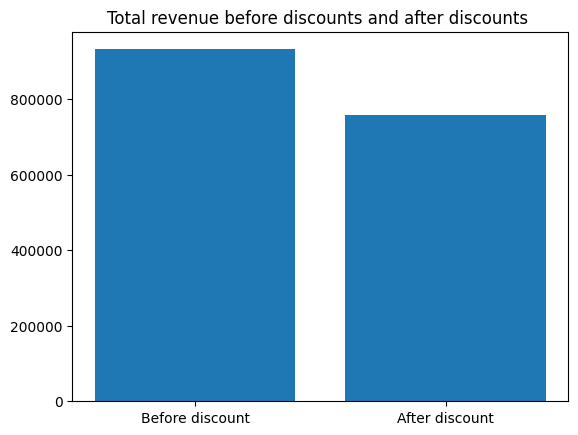

In [ ]:
plt.title('Total revenue before discounts and after discounts ')
plt.bar(['Before discount','After discount'],[total_revenue_before_discount,total_revenue_after_discount])
plt.show()

# Which category receives the highest discounts?

In [ ]:
catagory_discounts=df.groupby(['Category'])['Discount (%)'].mean().sort_values(ascending=False)
catagory_discounts

,Discount (%)
Category,
Home & Kitchen,19.608379
Sports,19.326923
Electronics,19.267068
Books,19.035581
Beauty,18.475248
Toys,18.126195
Clothing,17.919021


In [ ]:
highest_catagory_discount=catagory_discounts.max()
print("Category that receives highest discount is : ",catagory_discounts.idxmax(),"=",highest_catagory_discount)

Category that receives highest discount is :  Home & Kitchen = 19.608378870673953


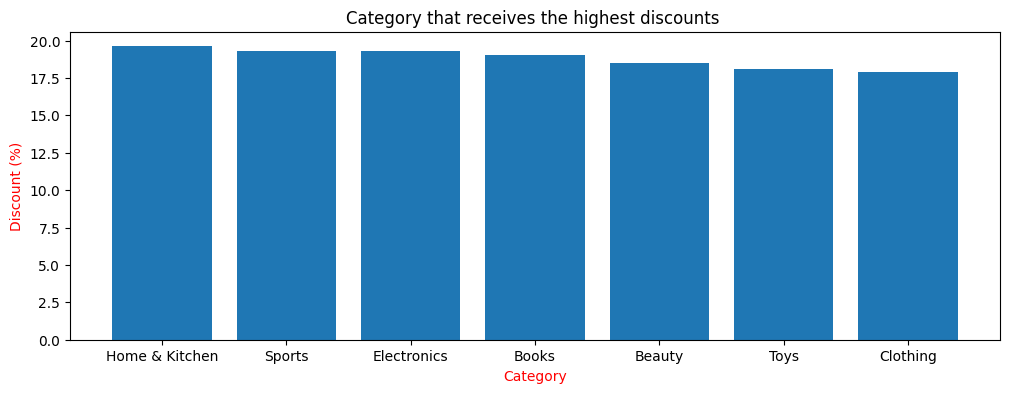

In [ ]:
plt.figure(figsize=(12,4))
plt.title("Category that receives the highest discounts ")
plt.bar(catagory_discounts.index,catagory_discounts.values)
plt.xlabel('Category',color='red')
plt.ylabel('Discount (%)',color='red')
plt.show()

In [ ]:
highest_catagory_discount=catagory_discounts.max()
print("Category that receives highest discount is : ",catagory_discounts.idxmax(),"=",highest_catagory_discount)

Category that receives highest discount is :  Home & Kitchen = 19.608378870673953


In [ ]:
highest_catagory_discount=catagory_discounts.max()
print("Category that receives highest discount is : ",catagory_discounts.idxmax(),"=",highest_catagory_discount)

Category that receives highest discount is :  Home & Kitchen = 19.608378870673953


In [ ]:
highest_catagory_discount=catagory_discounts.max()
print("Category that receives highest discount is : ",catagory_discounts.idxmax(),"=",highest_catagory_discount)

Category that receives highest discount is :  Home & Kitchen = 19.608378870673953
